In [ ]:
# ============================================================
# SETUP - Correr esta celda primero
# ============================================================
!git clone https://github.com/tatipar/temporalgnn-nids.git
import sys
sys.path.append('/content/temporalgnn-nids/code/python')

from google.colab import drive
drive.mount('/content/drive')


In [ ]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi


In [ ]:
from utils.visualization import (
    plot_training_losses, plot_losses_train_val_per_model,
    plot_comparison, plot_radar_chart,
    MODEL_NAME_MAPPING, MODEL_COLORS,
)


# Functions

## Load data

In [3]:
def load_json_losses(base_log_path="results_earlystopping/logs"):
    """
    Read the individual JSON by seed and extract the losses and early stopping
    Return: {'ModelName': {'seed_99': {'train': [...], 'val': [...], 'val_aucpr': [...], 'best_epoch': 25}, ...}}
    """
    losses = {}
    if not os.path.exists(base_log_path):
        print(f"Path not found: {base_log_path}")
        return losses

    for raw_model_name in os.listdir(base_log_path):
        model_dir = os.path.join(base_log_path, raw_model_name)
        if not os.path.isdir(model_dir): continue

        clean_model_name = MODEL_NAME_MAPPING.get(raw_model_name, raw_model_name)
        losses[raw_model_name] = {}
        json_files = glob.glob(os.path.join(model_dir, "*.json"))

        for jf in json_files:
            with open(jf, 'r') as f:
                data = json.load(f)

            if 'training' in data:
                seed_id = f"seed_{data.get('seed', 'unknown')}"

                losses[raw_model_name][seed_id] = {
                    'train': data['training'].get('train_loss', []),
                    'val': data['training'].get('val_loss', []),
                    'val_aucpr': data['training'].get('val_aucpr', []),
                    'best_epoch': data.get('early_stopping', {}).get('best_epoch', None)
                }

    return losses



In [13]:
def load_and_merge_csv_data(base_log_path="results_earlystopping/logs"):
    df_list = []
    if not os.path.exists(base_log_path): return None

    for raw_model_name in os.listdir(base_log_path):
        #csv_files = glob.glob(os.path.join(base_log_path, raw_model_name, "*.csv"))
        csv_files = glob.glob(os.path.join(base_log_path, raw_model_name, "metrics_newth_*.csv"))
        clean_model_name = MODEL_NAME_MAPPING.get(raw_model_name, raw_model_name)
        for csv_file in csv_files:
            df = pd.read_csv(csv_file)
            df.columns = df.columns.str.lower().str.strip()
            df['model'] = clean_model_name
            if len(df) > 0:
                df_list.append(df)

    if not df_list: return None
    return pd.concat(df_list, ignore_index=True)

## Summary table

In [9]:
def generate_summary_table(df):
    possible = ['precision', 'recall', 'f1', 'f2', 'auc-pr', 'auc-roc', 'fpr', 'optimal_threshold']
    metrics = [c for c in df.columns if c in possible]
    model_order = ["Simple MLP", "Edge GRU", "Static GNN", "ST-GNN (Ours)"]

    # Convert 'model' column to categorical type with the desired order
    df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

    summary = df.groupby('model', observed=False)[metrics].agg(['mean', 'std'])

    print("\n" + "="*80)
    print(" SUMMARY TABLE (Mean ± Std)")
    print("="*80)
    print(summary.round(4))

# Configuration

In [14]:
sns.set_theme(style="whitegrid")

MODEL_NAME_MAPPING = {
    'SimpleMLP_BiasOn': 'Simple MLP',
    'EdgeGRU_BiasOn': 'Edge GRU',
    'StaticGNN_BiasOn_robust_Identity': 'Static GNN',
    'ST_GNN_BiasOn_robust_Identity_clone': 'ST-GNN (Ours)'
}

colors = {
    "Simple MLP": "#95a5a6",   # Gray
    "Edge GRU": "#3498db",   # Blue
    "Static GNN": "#e67e22",     # Orange
    "ST-GNN (Ours)": "#2ecc71" # Green
}


# Main

In [15]:
ROOT_DIR = "./results_earlystopping"

LOGS_DIR = os.path.join(ROOT_DIR, "logs")
PLOTS_DIR = os.path.join(ROOT_DIR, "plots")

1. Loading data...

2. Generating Summary Table...

 SUMMARY TABLE (Mean ± Std)
              precision          recall              f1              f2  \
                   mean     std    mean     std    mean     std    mean   
model                                                                     
Simple MLP       0.4992  0.0499  0.1614  0.0147  0.2439  0.0223  0.1867   
Edge GRU         0.2624  0.0727  0.3329  0.0779  0.2832  0.0457  0.3075   
Static GNN       0.5269  0.1673  0.3719  0.0556  0.4315  0.1003  0.3927   
ST-GNN (Ours)    0.7454  0.0546  0.7742  0.0609  0.7564  0.0183  0.7662   

                       auc-pr         auc-roc             fpr          \
                  std    mean     std    mean     std    mean     std   
model                                                                   
Simple MLP     0.0170  0.1955  0.0244  0.7883  0.0186  0.0067  0.0008   
Edge GRU       0.0519  0.2327  0.0775  0.8328  0.0443  0.0429  0.0215   
Static GNN     0.0717  0.4024

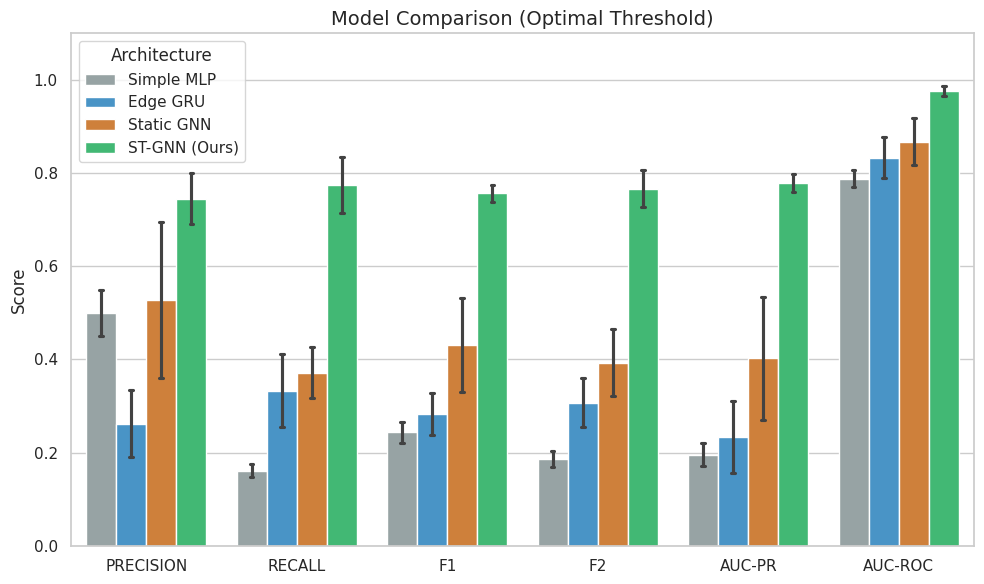


4. Generating Radar Chart...


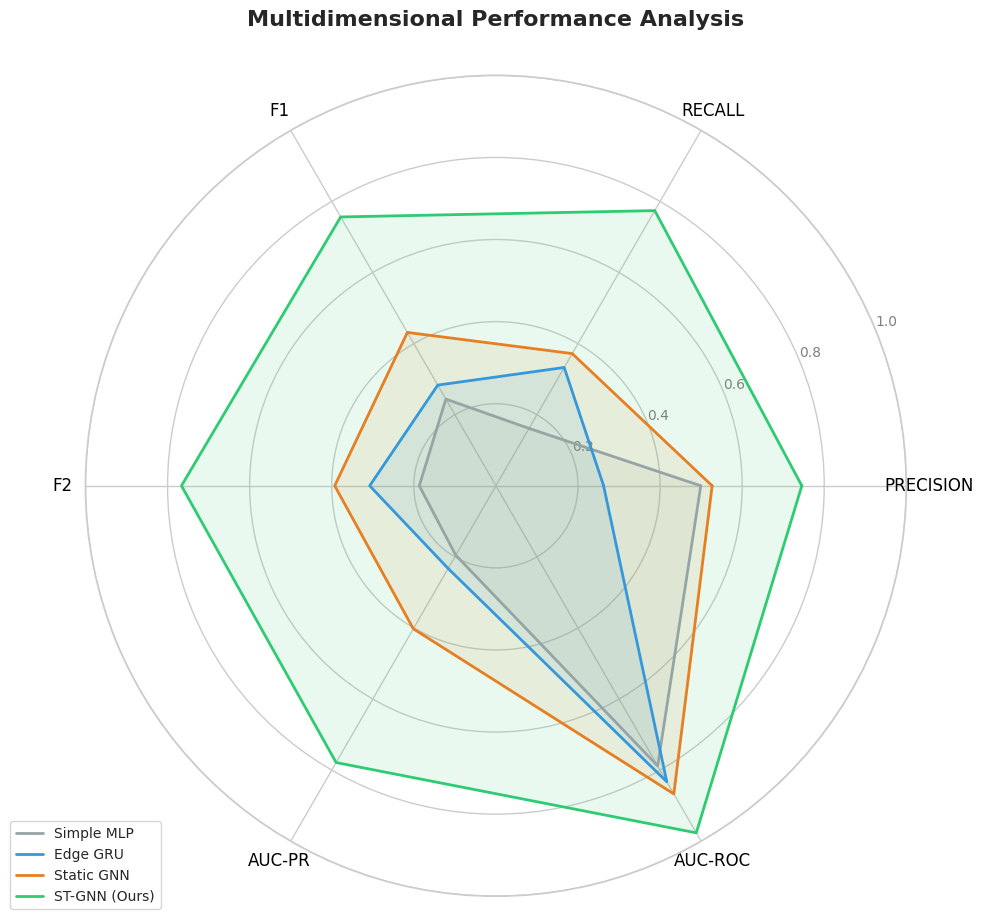


5. Generating Loss Curve Graphs...


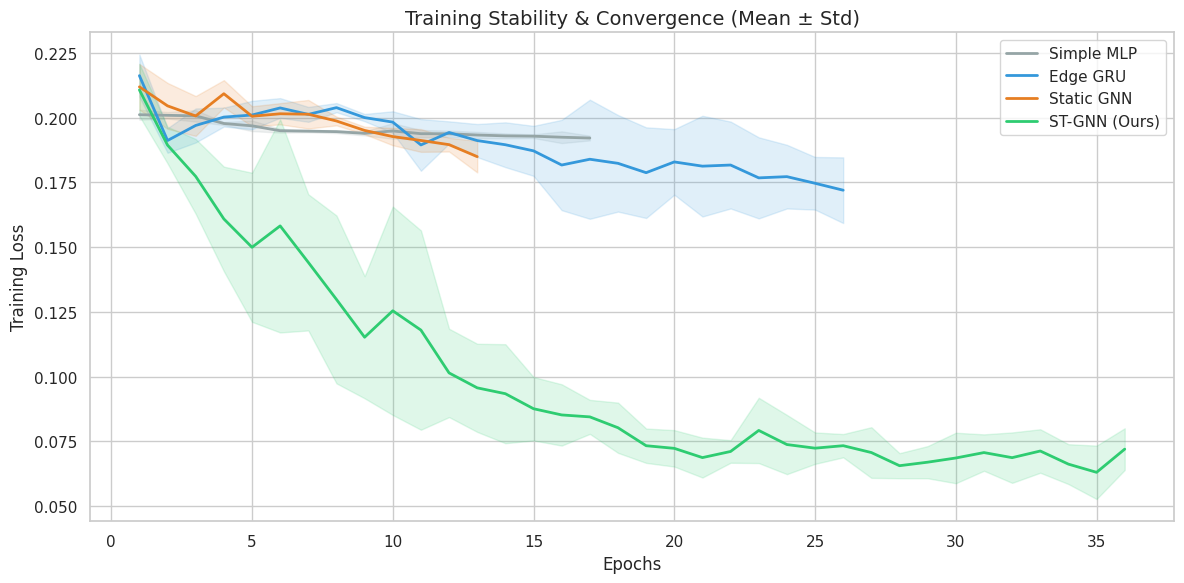

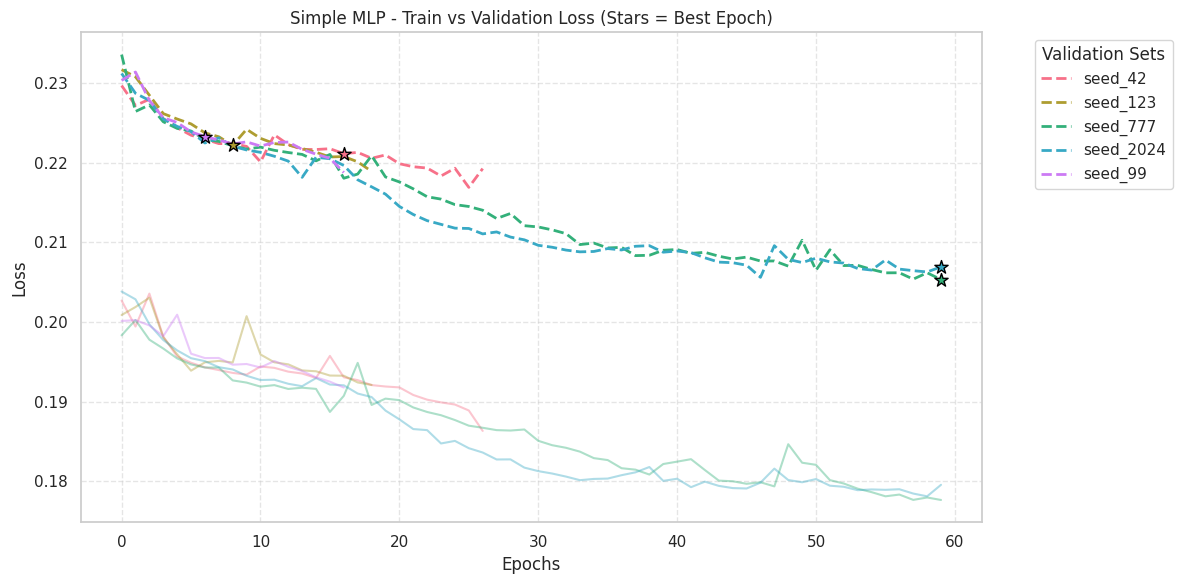

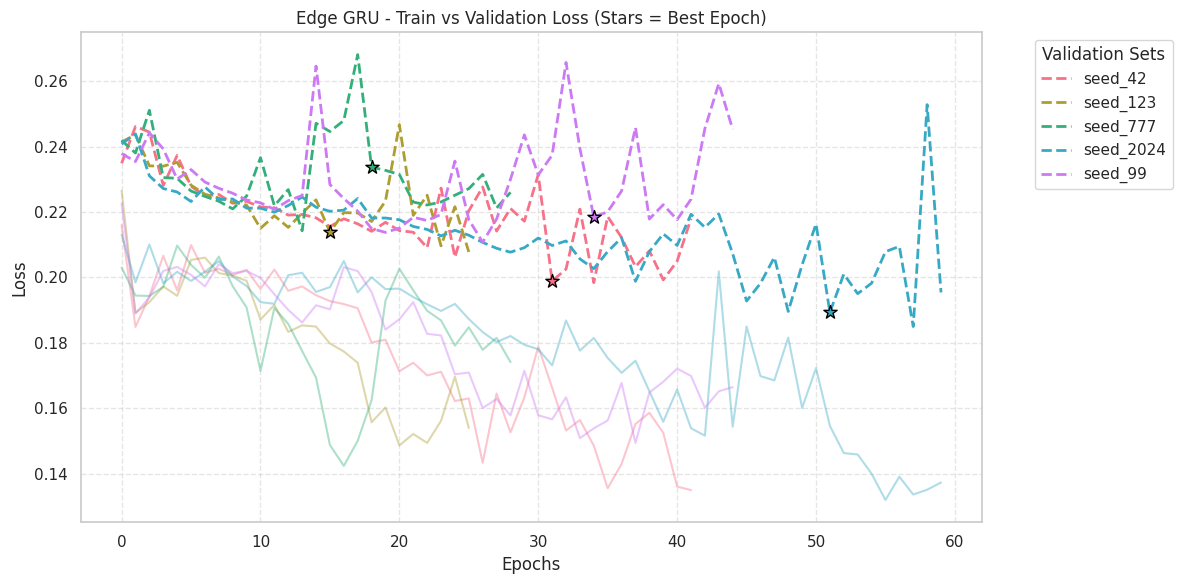

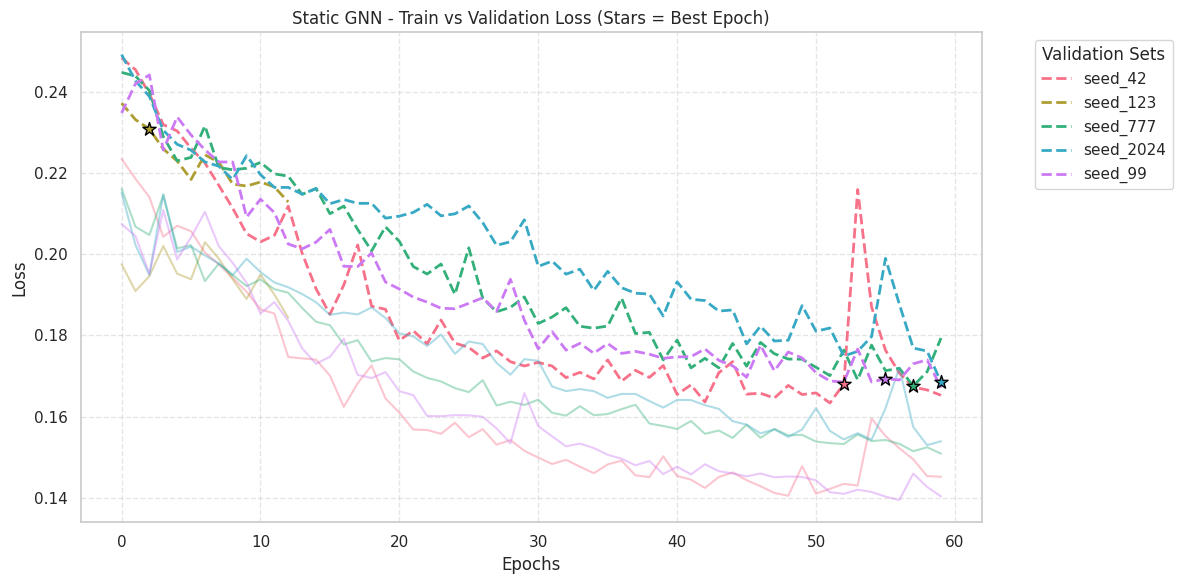

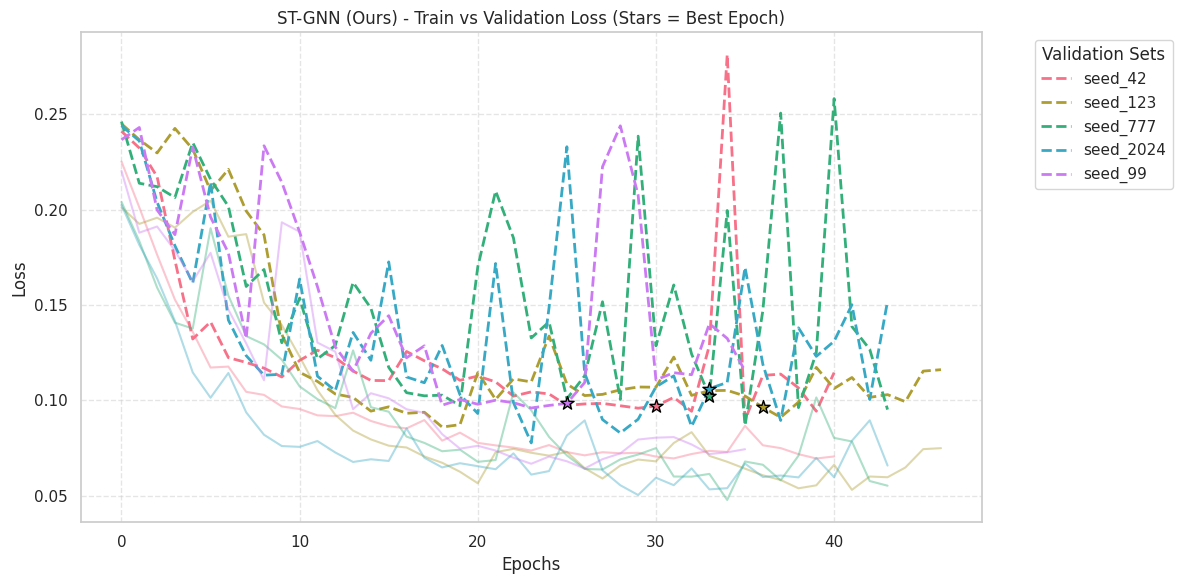


Analysis complete. Charts saved in folder ./results_earlystopping/plots


In [16]:
print("1. Loading data...")
losses_data = load_json_losses(LOGS_DIR)
df_metrics = load_and_merge_csv_data(LOGS_DIR)

if df_metrics is not None:
    print("\n2. Generating Summary Table...")
    generate_summary_table(df_metrics)

    print("\n3. Generating Comparison Chart (Bar Chart)...")
    plot_comparison(df_metrics, PLOTS_DIR)

    print("\n4. Generating Radar Chart...")
    plot_radar_chart(df_metrics, PLOTS_DIR)
else:
    print("No metrics CSV files were found")

if losses_data:
    print("\n5. Generating Loss Curve Graphs...")
    plot_training_losses(losses_data, PLOTS_DIR)
    for raw_model_name in losses_data.keys():
        plot_losses_train_val_per_model(losses_data, raw_model_name, PLOTS_DIR)
else:
    print("No losses JSON files were found")

print(f"\nAnalysis complete. Charts saved in folder {PLOTS_DIR}")